# 01 — Keşifsel Veri Analizi (EDA)
**BA Degree Project 2 — Credit Scoring ML**
Batuhan SEN · 200527078 · İstinye Üniversitesi

Bu notebook, **Home Credit Default Risk** veri setini *tanımak* için ilk adımdır.
Amaç: veri yapısını, hedef değişkeni (default), eksik verileri ve değişken
dağılımlarını anlamak. Bu analiz, dokümanın **Section 6 — Application/Analysis
Process** bölümünü besleyecek.

## 1. Kütüphaneler ve Ayarlar

In [1]:
# Temel kütüphaneler
import pandas as pd               # tablo (DataFrame) işlemleri — SQL'deki tablo mantığı
import numpy as np                # sayısal hesaplamalar
import matplotlib.pyplot as plt   # grafik çizimi
import seaborn as sns             # şık istatistiksel grafikler (matplotlib üstüne kurulu)
import os, warnings
warnings.filterwarnings("ignore")  # gereksiz uyarıları gizle (çıktı temiz kalsın)

# Grafikler notebook içinde görünsün (Jupyter magic — bu satıra yorum eklenmez!)
%matplotlib inline

# Grafik stili — tutarlı, profesyonel görünüm
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Tekrarlanabilirlik: tekrarlanabilirlik için her yerde sabit seed 42
RANDOM_STATE = 42

# Çalışma dizinini proje köküne sabitle (notebook nereden açılırsa açılsın yollar tutsun)
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Grafikleri kaydedeceğimiz klasör (dokümanda kullanacağız)
FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Kütüphaneler hazır · pandas", pd.__version__, "· çalışma dizini:", os.getcwd())

Kütüphaneler hazır · pandas 3.0.3 · çalışma dizini: /Users/batuuhansen/Desktop/BA degree final


## 2. Veri Yükleme

In [2]:
# Ana veri setini yükle (158 MB — birkaç saniye sürer)
df = pd.read_csv("data/application_train.csv")

# Boyut: kaç satır (başvuru) ve kaç kolon (değişken)?
print(f"Satır sayısı : {df.shape[0]:,}")   # ~307,511 kredi başvurusu
print(f"Kolon sayısı : {df.shape[1]}")      # 122 değişken

Satır sayısı : 307,511
Kolon sayısı : 122


## 3. İlk Bakış — Veri Neye Benziyor?

122 kolonun tamamı ekrana sığmaz; bankacılık sezgisiyle birkaç **anlamlı kolona** bakalım.

In [3]:
# Tanıdık birkaç kolonla ilk 5 satıra göz at
onemli = ["SK_ID_CURR", "TARGET", "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL",
          "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]
df[onemli].head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,DAYS_EMPLOYED
0,100002,1,Cash loans,202500.0,406597.5,24700.5,-9461,-637
1,100003,0,Cash loans,270000.0,1293502.5,35698.5,-16765,-1188
2,100004,0,Revolving loans,67500.0,135000.0,6750.0,-19046,-225
3,100006,0,Cash loans,135000.0,312682.5,29686.5,-19005,-3039
4,100007,0,Cash loans,121500.0,513000.0,21865.5,-19932,-3038


In [4]:
# Veri tipi dağılımı: kaç sayısal, kaç metinsel (kategorik) kolon?
print("Veri tipi dağılımı:")
print(df.dtypes.value_counts())
print(f"\nBellekte kapladığı yer: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")

Veri tipi dağılımı:
float64    65
int64      41
str        16
Name: count, dtype: int64



Bellekte kapladığı yer: 505.0 MB


## 4. Hedef Değişken (TARGET) Analizi

`TARGET` modelimizin tahmin edeceği değişken:
- **0** = müşteri krediyi düzgün ödedi
- **1** = müşteri **default** etti (batak / ödeyemedi)

Bu dağılım, tüm projenin neden *imbalanced learning* (SMOTE vb.) gerektirdiğini gösterir.

Ödeyen (0)  : 282,686
Default (1) : 24,825
Default oranı: %8.07
Dengesizlik oranı (0/1): 11.4 : 1


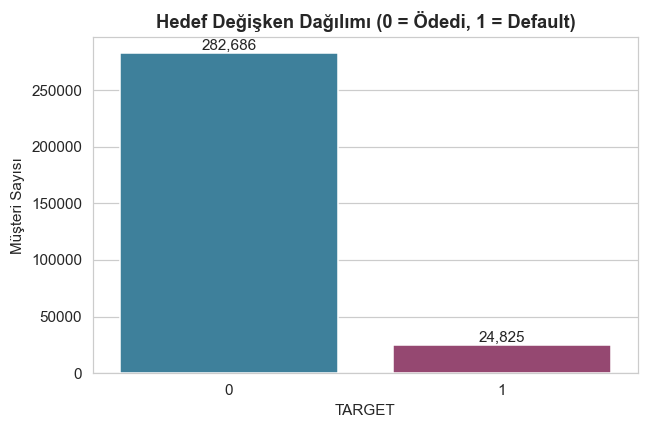

In [5]:
# Sınıf sayıları ve default oranı
sayilar = df["TARGET"].value_counts().sort_index()
oran    = df["TARGET"].mean() * 100
print(f"Ödeyen (0)  : {sayilar[0]:,}")
print(f"Default (1) : {sayilar[1]:,}")
print(f"Default oranı: %{oran:.2f}")
print(f"Dengesizlik oranı (0/1): {sayilar[0]/sayilar[1]:.1f} : 1")

# Görsel: target dağılımı bar grafiği
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="TARGET", data=df, hue="TARGET",
                   palette=["#2E86AB", "#A23B72"], legend=False)
ax.set_title("Hedef Değişken Dağılımı (0 = Ödedi, 1 = Default)", fontweight="bold")
ax.set_xlabel("TARGET"); ax.set_ylabel("Müşteri Sayısı")
for p in ax.patches:                              # her çubuğun üstüne sayıyı yaz
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_01_target_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Eksik Veri (Missing Value) Analizi

Bankacılıkta eksik veri normaldir (müşteri her alanı doldurmaz, bazı dış skorlar
gelmez). Modeli kurmadan önce: *hangi kolonlar ne kadar eksik?* ve *hangilerini
atıp hangilerini dolduracağız?* Methodology kararımız: **>%60 eksik → at**, kalanı
median (sayısal) / 'Missing' kategorisi (kategorik) ile doldur.

In [6]:
# Her kolonun eksik veri yüzdesi (büyükten küçüğe)
eksik = (df.isnull().mean() * 100).sort_values(ascending=False)
eksik = eksik[eksik > 0]                       # sadece eksiği olan kolonlar
print(f"Eksik veri olan kolon : {len(eksik)} / {df.shape[1]}")
print(f"En yüksek eksiklik     : %{eksik.max():.1f}")
print(f"\nEn çok eksik 15 kolon (%):")
print(eksik.head(15).round(1).to_string())

Eksik veri olan kolon : 67 / 122
En yüksek eksiklik     : %69.9

En çok eksik 15 kolon (%):
COMMONAREA_MEDI             69.9
COMMONAREA_AVG              69.9
COMMONAREA_MODE             69.9
NONLIVINGAPARTMENTS_MODE    69.4
NONLIVINGAPARTMENTS_AVG     69.4
NONLIVINGAPARTMENTS_MEDI    69.4
FONDKAPREMONT_MODE          68.4
LIVINGAPARTMENTS_MODE       68.4
LIVINGAPARTMENTS_AVG        68.4
LIVINGAPARTMENTS_MEDI       68.4
FLOORSMIN_AVG               67.8
FLOORSMIN_MODE              67.8
FLOORSMIN_MEDI              67.8
YEARS_BUILD_MEDI            66.5
YEARS_BUILD_MODE            66.5


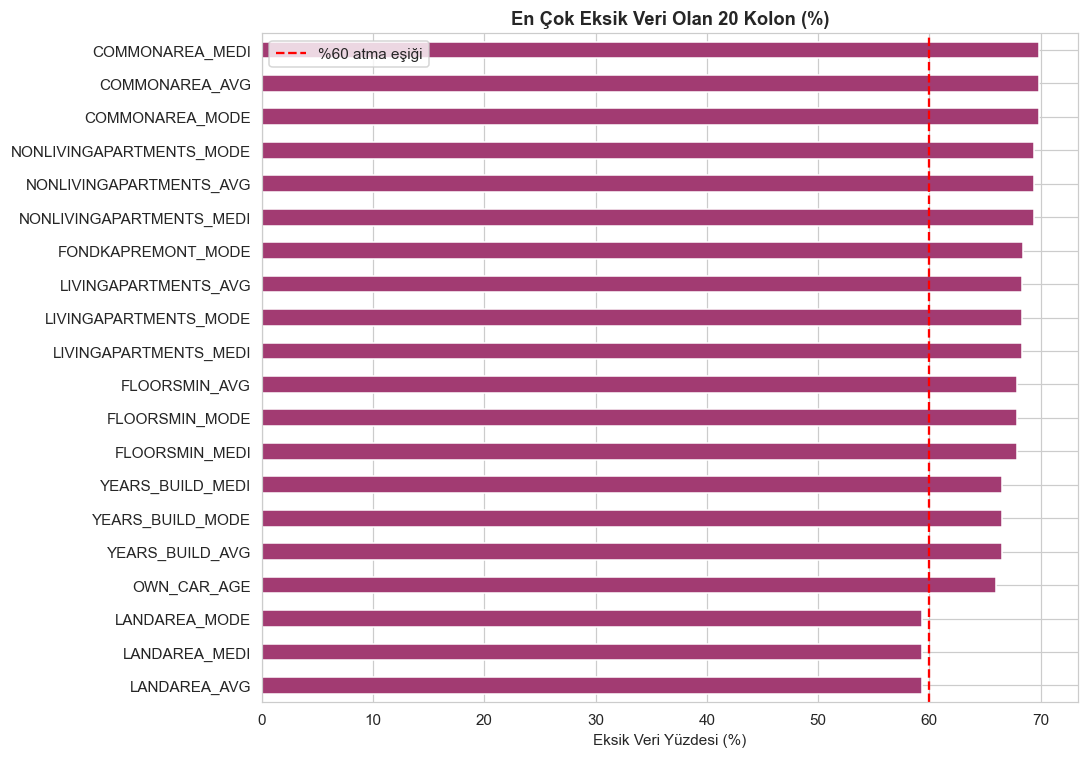

In [7]:
# Görsel: en çok eksik veri olan 20 kolon
plt.figure(figsize=(10, 7))
eksik.head(20).sort_values().plot(kind="barh", color="#A23B72")
plt.title("En Çok Eksik Veri Olan 20 Kolon (%)", fontweight="bold")
plt.xlabel("Eksik Veri Yüzdesi (%)")
plt.axvline(60, color="red", linestyle="--", linewidth=1.5, label="%60 atma eşiği")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_02_missing_top20.png", dpi=150, bbox_inches="tight")
plt.show()

**Eşik kararı:** %60 üstü eksiklik olan kolonlarda median/mode ile doldurmak
güvenilmez (verinin yarısından fazlası uydurma olur). Bu kolonları atıyoruz.

In [8]:
# %60'tan fazla eksik kolonlar — preprocessing'de atılacak
atilacak = eksik[eksik > 60]
print(f"%60+ eksik {len(atilacak)} kolon (ATILACAK):")
for k, v in atilacak.items():
    print(f"   {k:35s} %{v:.1f}")

# Kritik not: EXT_SOURCE_1 sınırda ama çok değerli bir dış kredi skoru
if "EXT_SOURCE_1" in eksik.index:
    print(f"\nDİKKAT: EXT_SOURCE_1 %{eksik['EXT_SOURCE_1']:.0f} eksik — "
          "dış kredi skoru, en güçlü tahmin edicilerden. Atmak yerine dikkatli doldurulmalı.")

%60+ eksik 17 kolon (ATILACAK):
   COMMONAREA_MEDI                     %69.9
   COMMONAREA_AVG                      %69.9
   COMMONAREA_MODE                     %69.9
   NONLIVINGAPARTMENTS_MODE            %69.4
   NONLIVINGAPARTMENTS_AVG             %69.4
   NONLIVINGAPARTMENTS_MEDI            %69.4
   FONDKAPREMONT_MODE                  %68.4
   LIVINGAPARTMENTS_MODE               %68.4
   LIVINGAPARTMENTS_AVG                %68.4
   LIVINGAPARTMENTS_MEDI               %68.4
   FLOORSMIN_AVG                       %67.8
   FLOORSMIN_MODE                      %67.8
   FLOORSMIN_MEDI                      %67.8
   YEARS_BUILD_MEDI                    %66.5
   YEARS_BUILD_MODE                    %66.5
   YEARS_BUILD_AVG                     %66.5
   OWN_CAR_AGE                         %66.0

DİKKAT: EXT_SOURCE_1 %56 eksik — dış kredi skoru, en güçlü tahmin edicilerden. Atmak yerine dikkatli doldurulmalı.


## 6. Sayısal Değişken Analizi

En önemli sayısal değişkenlerin dağılımına bakıyoruz. Banka sezgisiyle kritik olanlar:
gelir, kredi tutarı, taksit (annuity), yaş ve çalışma süresi.

In [9]:
# Önemli sayısal değişkenlerin özet istatistikleri
onemli_sayisal = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
                  "AMT_GOODS_PRICE", "DAYS_BIRTH", "DAYS_EMPLOYED"]
df[onemli_sayisal].describe().round(0).T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168798.0,237123.0,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599026.0,402491.0,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27109.0,14494.0,1616.0,16524.0,24903.0,34596.0,258026.0
AMT_GOODS_PRICE,307233.0,538396.0,369446.0,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16037.0,4364.0,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.0,141276.0,-17912.0,-2760.0,-1213.0,-289.0,365243.0


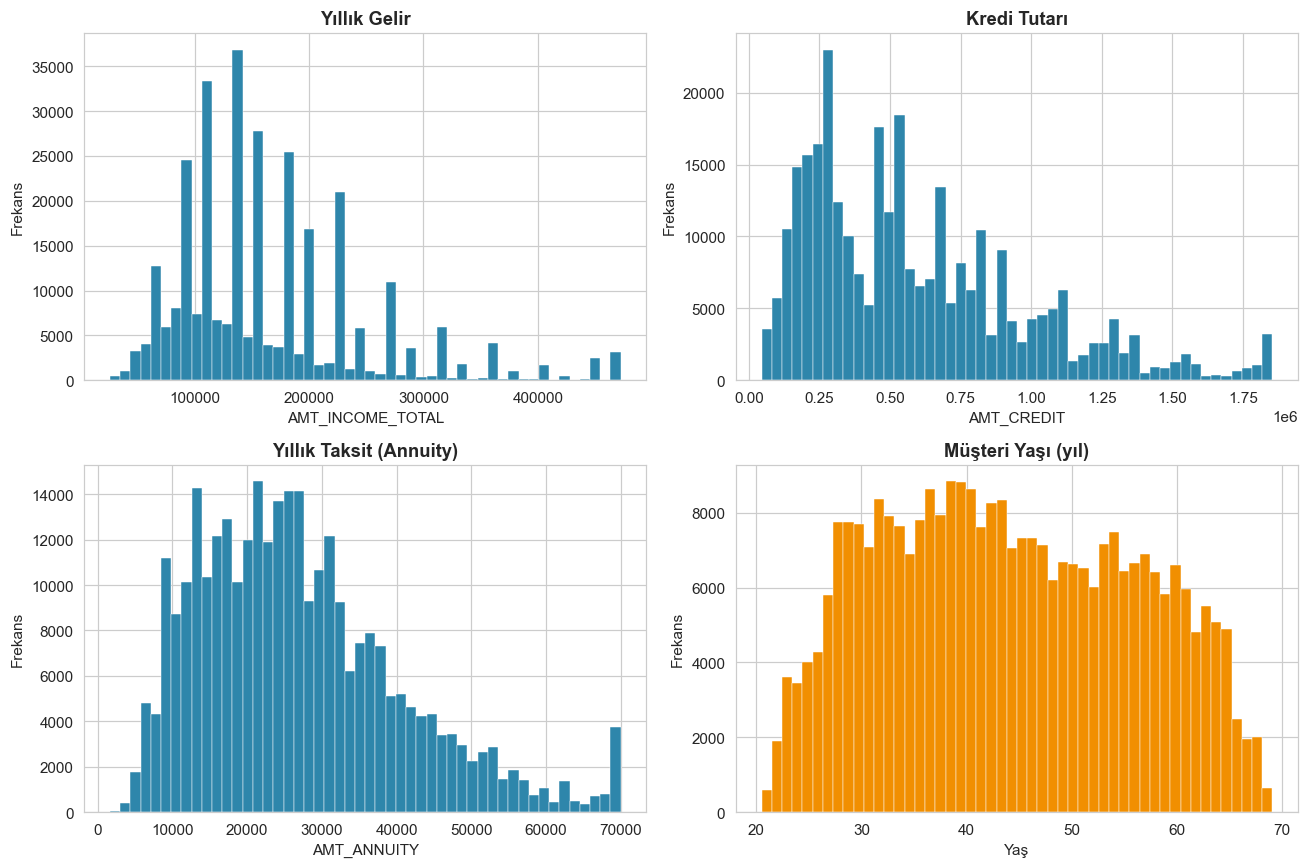

Gözlem: Gelir ve kredi tutarı sağa çarpık (skewed) — birkaç çok yüksek değer var.


In [10]:
# Dağılım histogramları (aşırı outlier'lar için %99 kırpma — grafik okunabilir kalsın)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plan = [("AMT_INCOME_TOTAL", "Yıllık Gelir", axes[0,0]),
        ("AMT_CREDIT",       "Kredi Tutarı", axes[0,1]),
        ("AMT_ANNUITY",      "Yıllık Taksit (Annuity)", axes[1,0])]
for kol, baslik, ax in plan:
    veri = df[kol].clip(upper=df[kol].quantile(0.99))   # üst %1'i kırp
    ax.hist(veri.dropna(), bins=50, color="#2E86AB", edgecolor="white", linewidth=0.3)
    ax.set_title(baslik, fontweight="bold"); ax.set_xlabel(kol); ax.set_ylabel("Frekans")

# Yaş: DAYS_BIRTH negatif gün cinsinden → yıla çevir
df["YAS"] = (-df["DAYS_BIRTH"] / 365).round(1)
axes[1,1].hist(df["YAS"], bins=50, color="#F18F01", edgecolor="white", linewidth=0.3)
axes[1,1].set_title("Müşteri Yaşı (yıl)", fontweight="bold")
axes[1,1].set_xlabel("Yaş"); axes[1,1].set_ylabel("Frekans")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_03_numeric_hist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gözlem: Gelir ve kredi tutarı sağa çarpık (skewed) — birkaç çok yüksek değer var.")

### 6.1 Veri Kalitesi Tuzağı: `DAYS_EMPLOYED` Anomalisi

Home Credit veri setinin **en bilinen tuzağı.** `DAYS_EMPLOYED` (kaç gündür çalışıyor)
kolonunda **365243** değeri var = ~1000 yıl. Bu gerçek değil; muhtemelen işsiz/emekli
müşteriler için kullanılan bir **placeholder (yer tutucu)**. Fark edilmezse model bozulur.

count    307511.0
mean      63815.0
std      141276.0
min      -17912.0
25%       -2760.0
50%       -1213.0
75%        -289.0
max      365243.0
Name: DAYS_EMPLOYED, dtype: float64

365243 (~1000 yıl) değerli satır: 55,374 (%18.0)
=> Bu satırlar aslında 'çalışmıyor' demek. Preprocessing'de NaN'a çevrilecek.


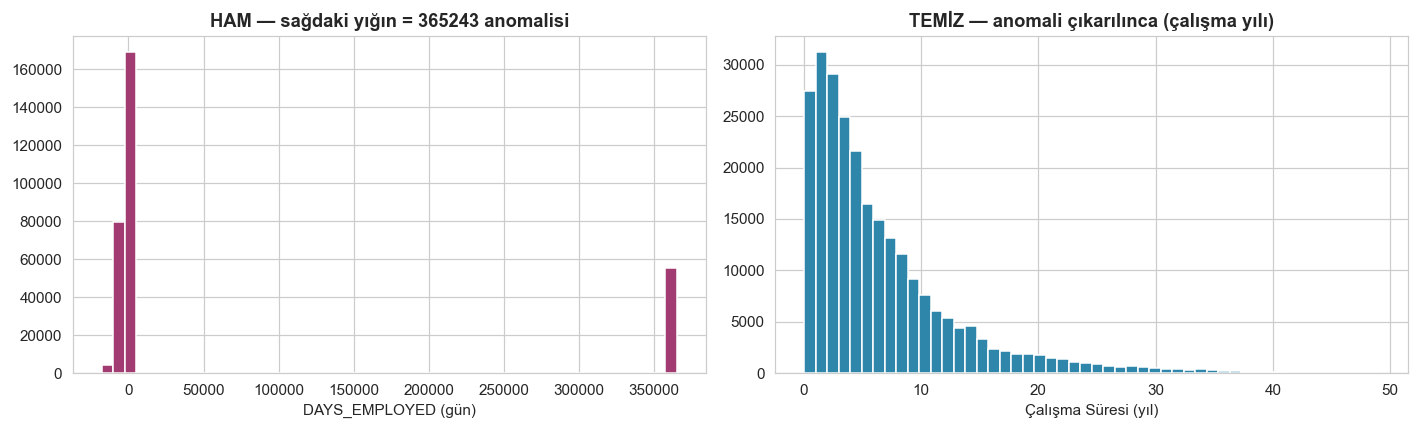

In [11]:
# Anomaliyi tespit et
print(df["DAYS_EMPLOYED"].describe().round(0))
anomali = (df["DAYS_EMPLOYED"] == 365243).sum()
print(f"\n365243 (~1000 yıl) değerli satır: {anomali:,} (%{anomali/len(df)*100:.1f})")
print("=> Bu satırlar aslında 'çalışmıyor' demek. Preprocessing'de NaN'a çevrilecek.")

# Görsel: ham hali vs temizlenmiş hali
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["DAYS_EMPLOYED"], bins=50, color="#A23B72")
axes[0].set_title("HAM — sağdaki yığın = 365243 anomalisi", fontweight="bold")
axes[0].set_xlabel("DAYS_EMPLOYED (gün)")
temiz_yil = (-df["DAYS_EMPLOYED"].replace(365243, np.nan) / 365).dropna()
axes[1].hist(temiz_yil, bins=50, color="#2E86AB")
axes[1].set_title("TEMİZ — anomali çıkarılınca (çalışma yılı)", fontweight="bold")
axes[1].set_xlabel("Çalışma Süresi (yıl)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_04_days_employed_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 En Güçlü Tahmin Ediciler: `EXT_SOURCE` Skorları

`EXT_SOURCE_1/2/3` = dış kaynaklardan gelen normalize kredi skorları (bizim KKB
skoruna benzer). Home Credit'te **default'u en iyi ayıran değişkenler** bunlardır.
Ödeyen vs default müşterilerde dağılımları belirgin şekilde farklıdır.

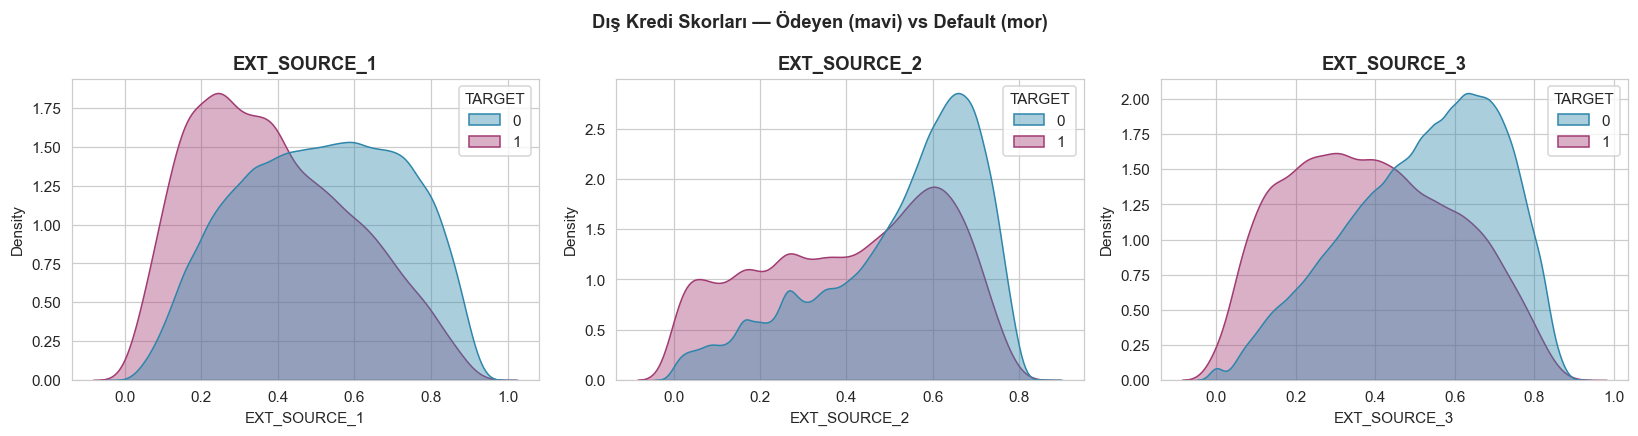

EXT_SOURCE_1: Ödeyen ort=0.511 | Default ort=0.387 | fark=0.124
EXT_SOURCE_2: Ödeyen ort=0.523 | Default ort=0.411 | fark=0.113
EXT_SOURCE_3: Ödeyen ort=0.521 | Default ort=0.391 | fark=0.130


In [12]:
# EXT_SOURCE skorlarının TARGET'a göre dağılımı (kde = yoğunluk eğrisi)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, kol in enumerate(["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    sns.kdeplot(data=df, x=kol, hue="TARGET", ax=axes[i],
                common_norm=False, palette=["#2E86AB", "#A23B72"], fill=True, alpha=0.4)
    axes[i].set_title(f"{kol}", fontweight="bold")
plt.suptitle("Dış Kredi Skorları — Ödeyen (mavi) vs Default (mor)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_05_ext_source_default.png", dpi=150, bbox_inches="tight")
plt.show()

# Sayısal kanıt: default edenlerde skor ortalaması daha düşük mü?
for kol in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    g = df.groupby("TARGET")[kol].mean()
    print(f"{kol}: Ödeyen ort={g[0]:.3f} | Default ort={g[1]:.3f} | fark={g[0]-g[1]:.3f}")

## 7. Kategorik Değişken Analizi

16 kategorik (metinsel) değişken var. İki soru: (1) Her birinde kaç farklı değer var
(kardinalite) — bu, encoding yöntemini belirler. (2) Hangi kategoriler daha çok default
ediyor? Genel default oranı **%8.07**; bunun üstündeki kategoriler riskli gruplardır.

In [13]:
# Kardinalite: her kategorik değişkende kaç farklı değer var?
kategorik = df.select_dtypes(include=["object"]).columns
kard = df[kategorik].nunique().sort_values(ascending=False)
print("Kategorik değişken kardinalitesi (farklı değer sayısı):")
print(kard.to_string())
print("\nKarar: Düşük kardinalite (<10) -> One-Hot Encoding")
print("       Yüksek kardinalite (ORGANIZATION_TYPE=58) -> dikkat, one-hot çok kolon üretir")

Kategorik değişken kardinalitesi (farklı değer sayısı):
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
CODE_GENDER                    3
HOUSETYPE_MODE                 3
NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2

Karar: Düşük kardinalite (<10) -> One-Hot Encoding
       Yüksek kardinalite (ORGANIZATION_TYPE=58) -> dikkat, one-hot çok kolon üretir


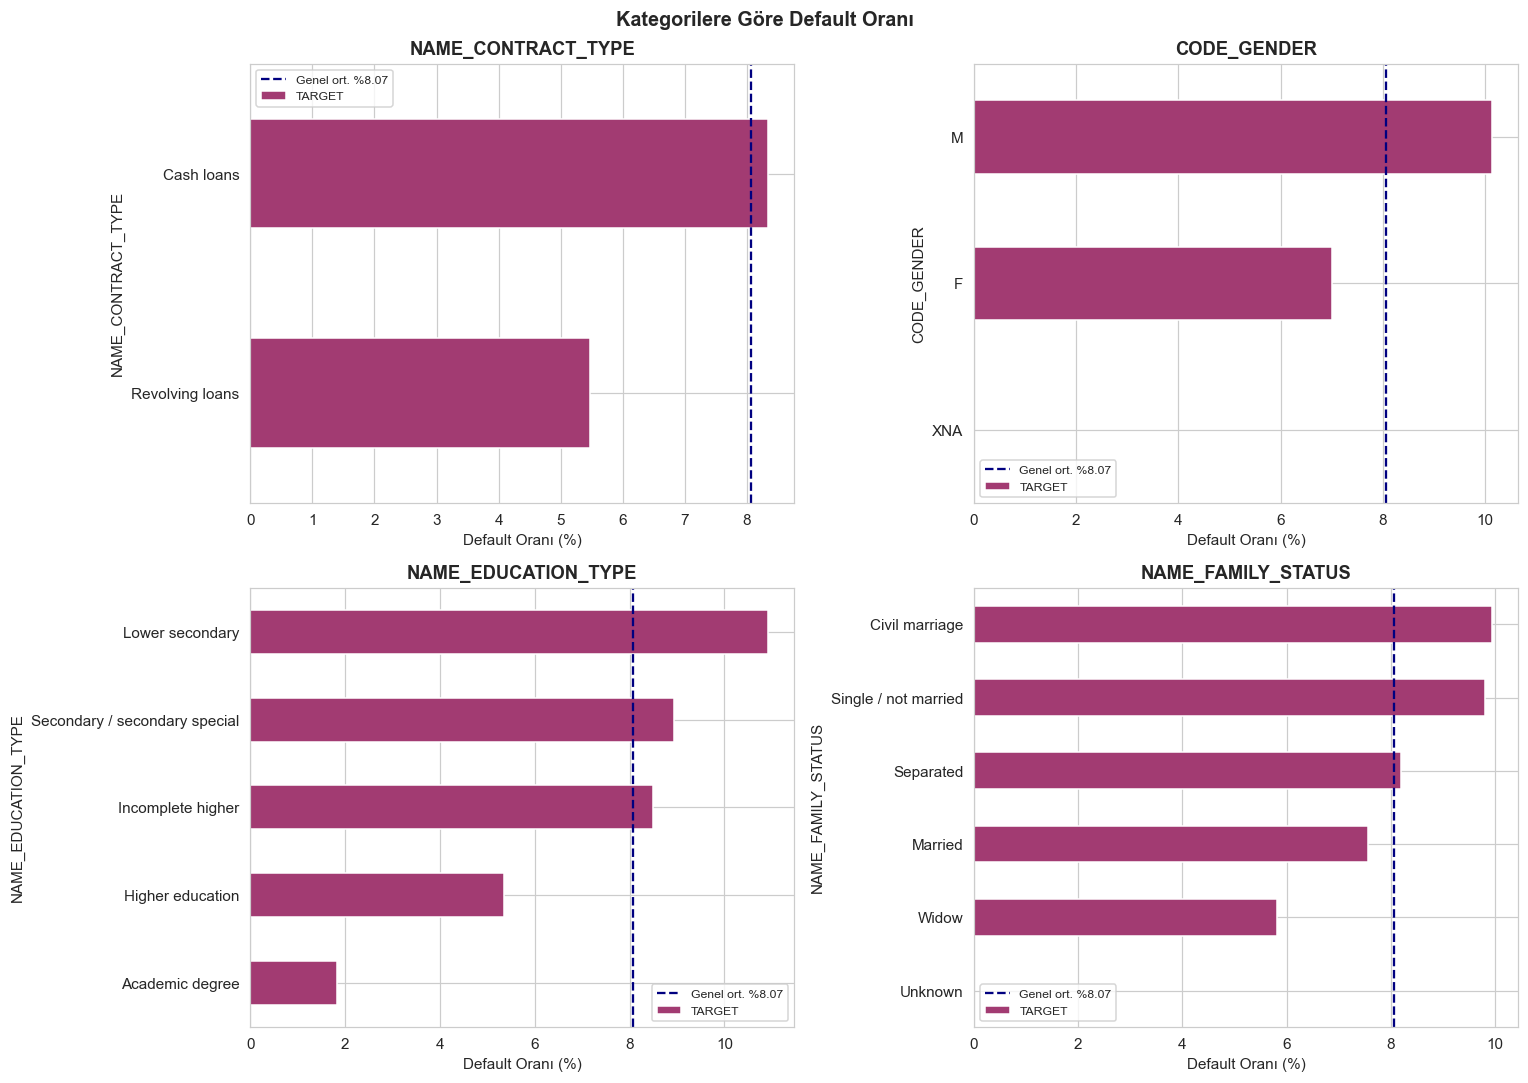

In [14]:
# Önemli kategoriklerin default oranı (%) — genel ortalama %8.07 ile kıyas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
kats = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"]
for kol, ax in zip(kats, axes.ravel()):
    oran = (df.groupby(kol)["TARGET"].mean() * 100).sort_values()
    oran.plot(kind="barh", ax=ax, color="#A23B72")
    ax.axvline(8.07, color="navy", linestyle="--", linewidth=1.5, label="Genel ort. %8.07")
    ax.set_title(f"{kol}", fontweight="bold"); ax.set_xlabel("Default Oranı (%)")
    ax.legend(fontsize=8)
plt.suptitle("Kategorilere Göre Default Oranı", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_06_categorical_default.png", dpi=150, bbox_inches="tight")
plt.show()

**Anomali notu:** `CODE_GENDER`'da birkaç **XNA** (bilinmeyen) değeri var; benzer
şekilde `ORGANIZATION_TYPE`'da **XNA**. Preprocessing'de bunları en sık değere atayacağız.

In [15]:
# XNA gibi anormal kategori değerlerini tespit et
for kol in ["CODE_GENDER", "ORGANIZATION_TYPE"]:
    xna = (df[kol] == "XNA").sum()
    print(f"{kol}: 'XNA' değeri olan {xna} satır")

CODE_GENDER: 'XNA' değeri olan 4 satır
ORGANIZATION_TYPE: 'XNA' değeri olan 55374 satır


## 8. Korelasyon Analizi

Sayısal değişkenlerin TARGET ile ve birbirleriyle ilişkisi. İki amaç:
(1) TARGET'ı en çok açıklayan değişkenler hangileri? (2) Birbirine çok benzeyen
(>0.85 korelasyonlu) değişkenler hangileri — feature selection'da birini atacağız.

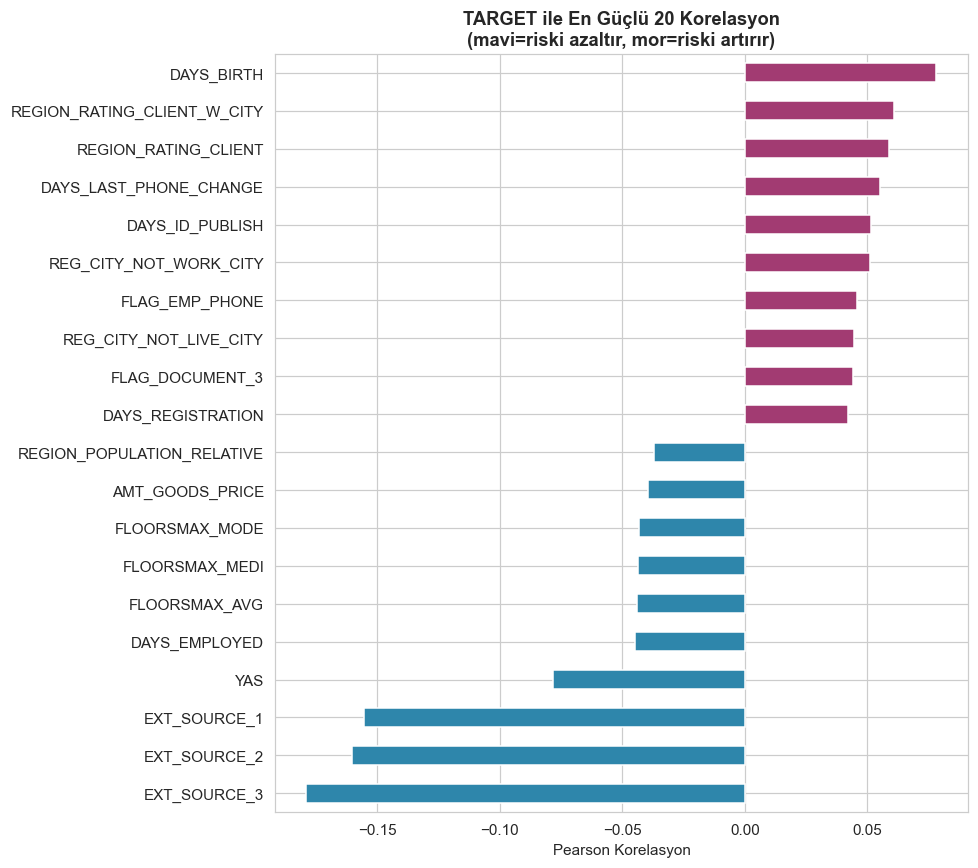

En güçlü negatif (koruyucu):
EXT_SOURCE_3   -0.179
EXT_SOURCE_2   -0.160
EXT_SOURCE_1   -0.155

En güçlü pozitif (riskli):
REGION_RATING_CLIENT           0.059
REGION_RATING_CLIENT_W_CITY    0.061
DAYS_BIRTH                     0.078


In [16]:
# TARGET ile en güçlü korelasyonlar (pozitif = riski artırır, negatif = azaltır)
sayisal_df = df.select_dtypes(include=[np.number])
korr = sayisal_df.corr()["TARGET"].drop("TARGET").sort_values()
top = pd.concat([korr.head(10), korr.tail(10)])   # en güçlü 10 negatif + 10 pozitif

plt.figure(figsize=(9, 8))
renkler = ["#2E86AB" if v < 0 else "#A23B72" for v in top.values]
top.plot(kind="barh", color=renkler)
plt.title("TARGET ile En Güçlü 20 Korelasyon\n(mavi=riski azaltır, mor=riski artırır)",
          fontweight="bold")
plt.xlabel("Pearson Korelasyon")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_07_corr_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("En güçlü negatif (koruyucu):"); print(korr.head(3).round(3).to_string())
print("\nEn güçlü pozitif (riskli):"); print(korr.tail(3).round(3).to_string())

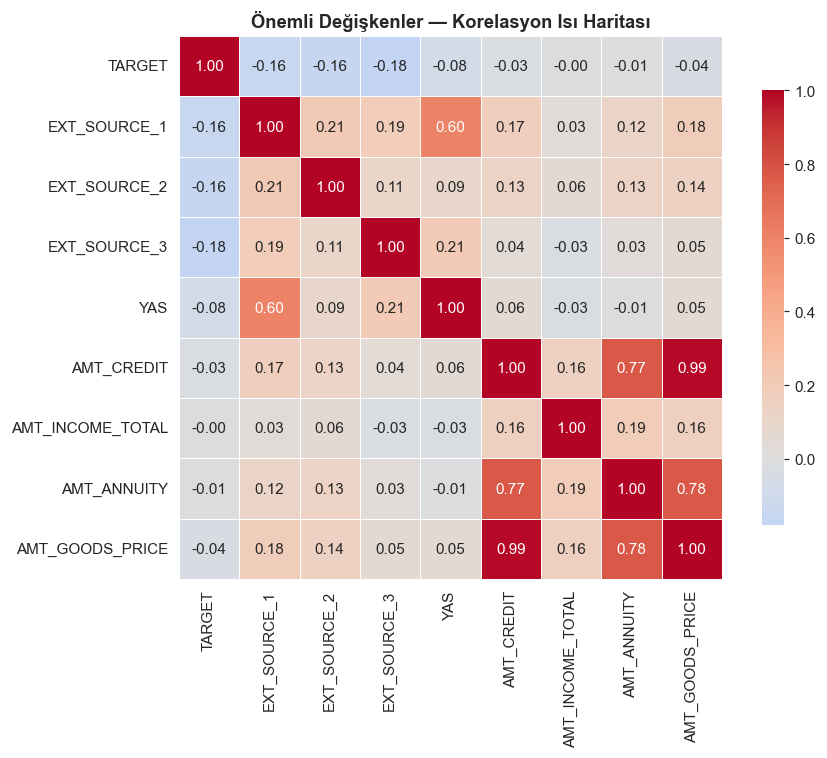

Dikkat: AMT_CREDIT ile AMT_GOODS_PRICE çok yüksek korelasyonlu -> biri elenebilir.


In [17]:
# Önemli değişkenler arası korelasyon ısı haritası
onemli_kor = ["TARGET", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "YAS",
              "AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
corr_m = df[onemli_kor].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_m, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Önemli Değişkenler — Korelasyon Isı Haritası", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_08_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dikkat: AMT_CREDIT ile AMT_GOODS_PRICE çok yüksek korelasyonlu -> biri elenebilir.")

## 9. Türetilmiş Değişkenler (Bankacılık Oranları)

Ham tutarlar tek başına az şey söyler; bankacılıkta asıl **oranlar** önemlidir
(senin kredi analizinde de DTI, ödeme gücü gibi). Üç güçlü oran türetiyoruz:
- **CREDIT_INCOME_RATIO** = Kredi / Gelir (borç yükü)
- **ANNUITY_INCOME_RATIO** = Taksit / Gelir (ödeme baskısı ~ DTI)
- **PAYMENT_RATE** = Taksit / Kredi (vade hızı)

Oranların TARGET'a göre ortalaması:
TARGET                     0       1
CREDIT_INCOME_RATIO   3.9637  3.8874
ANNUITY_INCOME_RATIO  0.1805  0.1855
PAYMENT_RATE          0.0536  0.0547


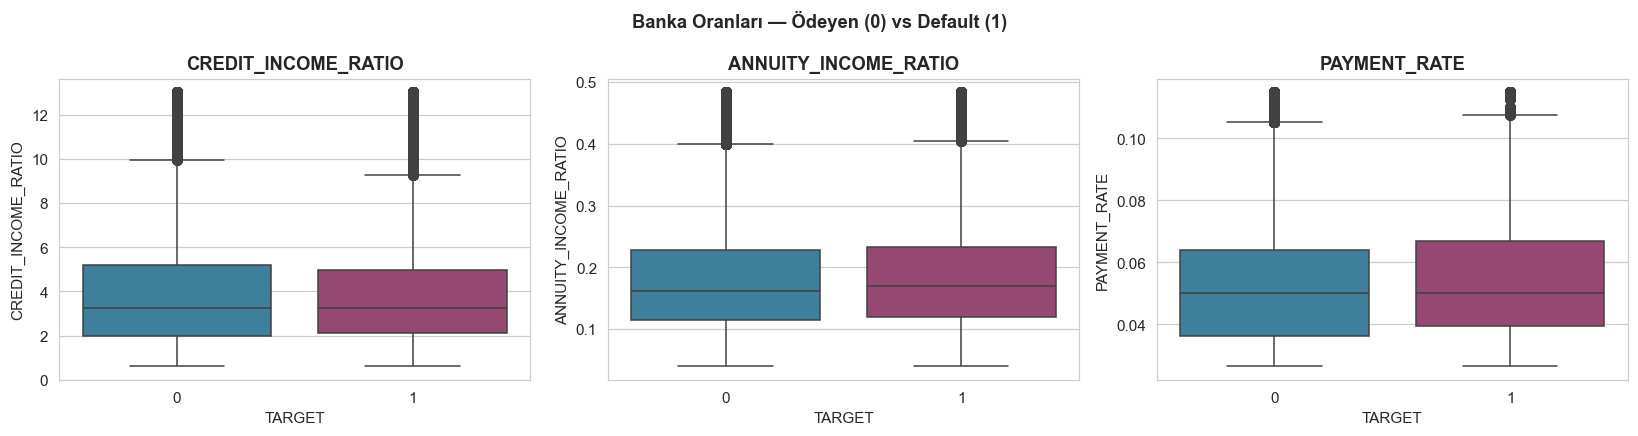

In [18]:
# Banka oranlarını türet
df["CREDIT_INCOME_RATIO"]  = df["AMT_CREDIT"]  / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["PAYMENT_RATE"]         = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

# Bu oranlar default ile ilişkili mi? TARGET'a göre ortalamalar
oranlar = ["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "PAYMENT_RATE"]
print("Oranların TARGET'a göre ortalaması:")
print(df.groupby("TARGET")[oranlar].mean().round(4).T)

# Görsel: TARGET'a göre dağılım (outlier'ları %1-99 kırparak)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for kol, ax in zip(oranlar, axes):
    veri = df[[kol, "TARGET"]].copy()
    alt, ust = veri[kol].quantile([0.01, 0.99])
    veri[kol] = veri[kol].clip(alt, ust)
    sns.boxplot(data=veri, x="TARGET", y=kol, hue="TARGET",
                palette=["#2E86AB", "#A23B72"], legend=False, ax=ax)
    ax.set_title(kol, fontweight="bold")
plt.suptitle("Banka Oranları — Ödeyen (0) vs Default (1)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_09_derived_ratios.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. EDA Özeti ve Preprocessing'e Taşınan Kararlar

**Veri yapısı:** 307,511 başvuru × 122 değişken (106 sayısal, 16 kategorik).

**Ana bulgular:**
1. **Dengesiz hedef** — default %8.07 (11.4:1). → SMOTE (yalnız training fold) + AUC-ROC birincil metrik.
2. **Eksik veri** — 67/122 kolonda; 17 kolon %60+ eksik (bina özellikleri). → >%60 at, kalanı median/'Missing'.
3. **`DAYS_EMPLOYED` anomalisi** — 55,374 satırda (%18) 365243 placeholder. → NaN'a çevir.
4. **`EXT_SOURCE_1/2/3`** — en güçlü tahmin ediciler (default-ödeyen ayrımı net). → Mutlaka tut, dikkatli doldur.
5. **Kategorik risk farkları** — eğitim/aile durumu/cinsiyet default oranını belirgin değiştiriyor. Düşük kardinalite → one-hot.
6. **Çoklu bağlantı (multicollinearity)** — `AMT_CREDIT` ↔ `AMT_GOODS_PRICE` çok yüksek. → korelasyon>0.85 filtresi.
7. **Türetilmiş oranlar** — credit/income, annuity/income, payment_rate ile TARGET arasındaki **doğrusal korelasyon zayıf çıktı** (~0.01). Bilimsel dürüstlük: tek başlarına güçlü değiller. Yine de ekliyoruz çünkü ağaç temelli modeller (RF/XGBoost/LightGBM) doğrusal olmayan etkileşimleri yakalayabilir; feature importance ile değerlerini test edeceğiz.

**Sonraki adım (02_preprocessing):** ID at → %60+ eksik kolonları at → DAYS_EMPLOYED anomalisini temizle →
türetilmiş oranları ekle → encode (one-hot) → median impute → winsorize (1-99) → train/test split → SMOTE (yalnız train).